# Sintesi degli spettri

Training supervised, vanno assegnate delle labels agli spettri. Ad ogni spettro assocerei **numero di picchi** e **posizioni dei picchi**. 

### Individuare i picchi con scipy

In [1]:
import numpy as np
from scipy.signal import find_peaks

def trova_dip_scipy(frequenze, spettro, soglia=-0.1):
    """
    Trova i dip (minimi) in uno spettro usando scipy.
    frequenze: asse x (es. array da 750 elementi)
    spettro: asse y (es. array da 750 elementi)
    soglia: valore sotto il quale considerare valido il dip
    """
    # find_peaks cerca i massimi, quindi invertiamo lo spettro
    # La soglia diventa positiva per la ricerca dei massimi
    indici_picchi, info = find_peaks(
        -spettro, 
        height=-soglia,
        prominence=0.00001,  # Prominenza minima del picco
        width=1 # Utile perché è la stima del gamma della lorentziana
    )
    
    # Estraiamo le posizioni in frequenza
    posizioni = frequenze[indici_picchi]
    
    return posizioni, info

def trova_picchi_scipy(frequenze, spettro, soglia=-0.1):
    """
    Trova i picchi in uno spettro usando scipy.
    frequenze: asse x (es. array da 750 elementi)
    spettro: asse y (es. array da 750 elementi)
    soglia: valore sotto il quale considerare valido il picco
    """
    # find_peaks cerca i massimi, quindi invertiamo lo spettro
    # La soglia diventa positiva per la ricerca dei massimi
    indici_picchi, info = find_peaks(
        spettro, 
        height=soglia,
        prominence=0.00001,  # Prominenza minima del picco
        width=1 # Utile perché è la stima del gamma della lorentziana
    )
    
    # Estraiamo le posizioni in frequenza
    posizioni = frequenze[indici_picchi]
    
    return posizioni, info

In [2]:
# Spettri
s = np.load('../data/X_spectra_50k.npy')#, mmap_mode='r')
# Corrispondenti campi magnetici
B = np.load('../data/Y_B_field_50k.npy')
# Asse x (frequenze)
f = np.arange(2500, 3250) 
x_axis = range(2500, 3250)

N_spettri, N_punti = s.shape[0], s.shape[1]

Cerco i picchi

In [3]:
# Liste per salvare i risultati di tutti gli spettri
num_picchi_totale = []
posizioni_totali = []
info_totale = [] 

for i in range(N_spettri):
    spettro_corrente = s[i]
    pos, info = trova_dip_scipy(f, spettro_corrente, soglia=-0.02)
    
    num_picchi_totale.append(len(pos))
    posizioni_totali.append(pos)
    info_totale.append(info)

Subito vediamo, nello spettro 2, un possibile problema. Lì ci sono chiaramente quattro dip, ma find_peaks non riesce a riconoscere quella spalla come un picco.

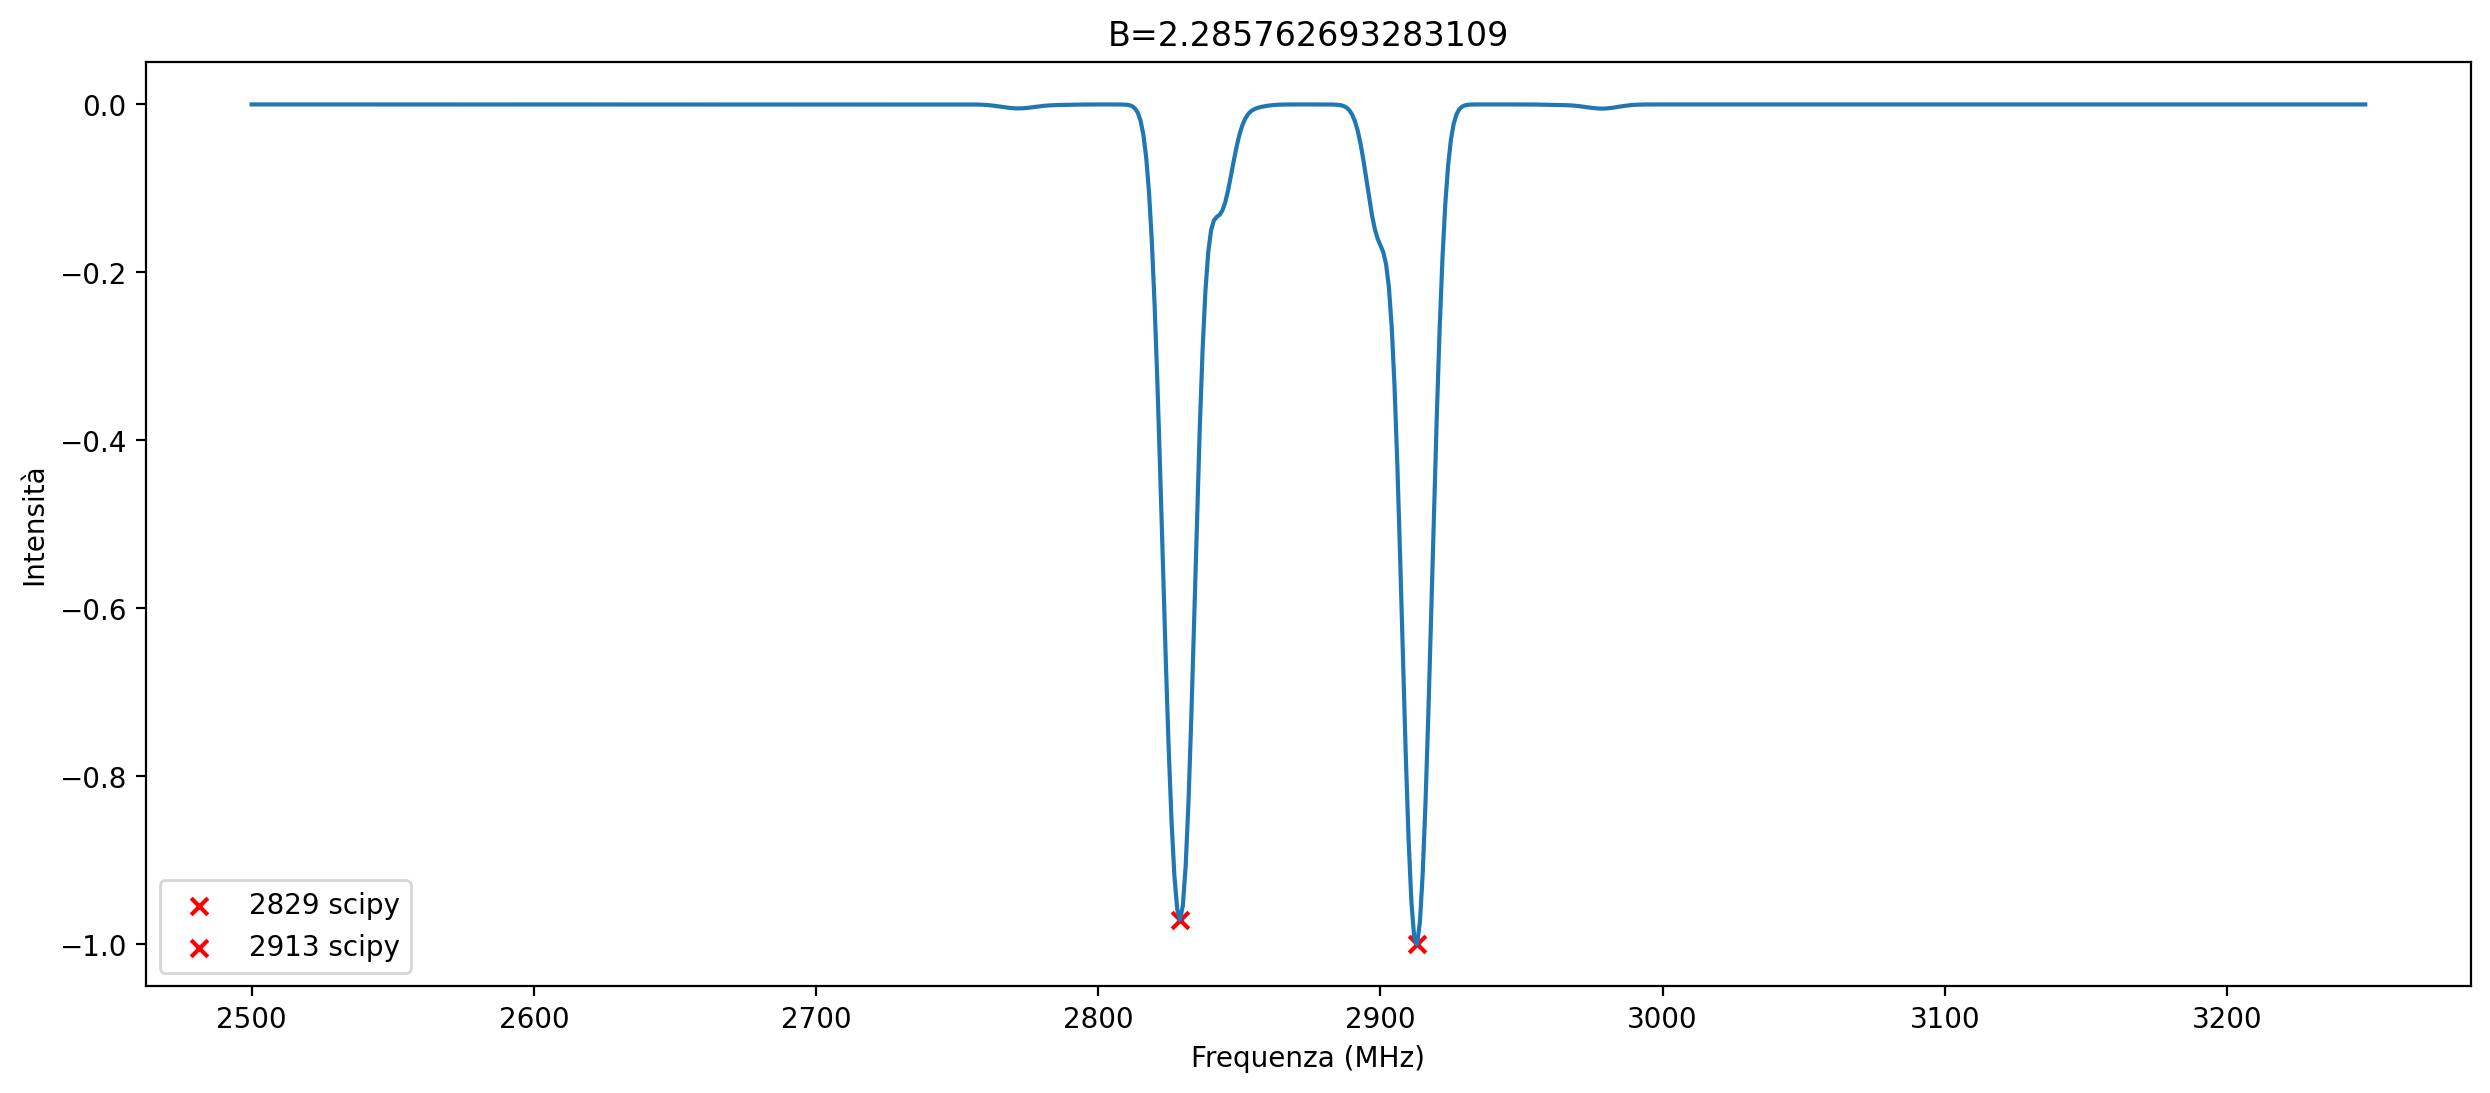

In [4]:
import matplotlib.pyplot as plt

for k in range(2, 3):  # Visualizziamo i primi 10 spettri
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(x_axis, s[k])
    for pos in posizioni_totali[k]:
        h = info_totale[k]['peak_heights'][np.where(posizioni_totali[k] == pos)[0][0]]
        plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
    plt.title(f"B={B[k]}")
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
    plt.legend()
    plt.show()

### Come sistemare?

---

provo a cercare le spalle nelle derivate dello spettro

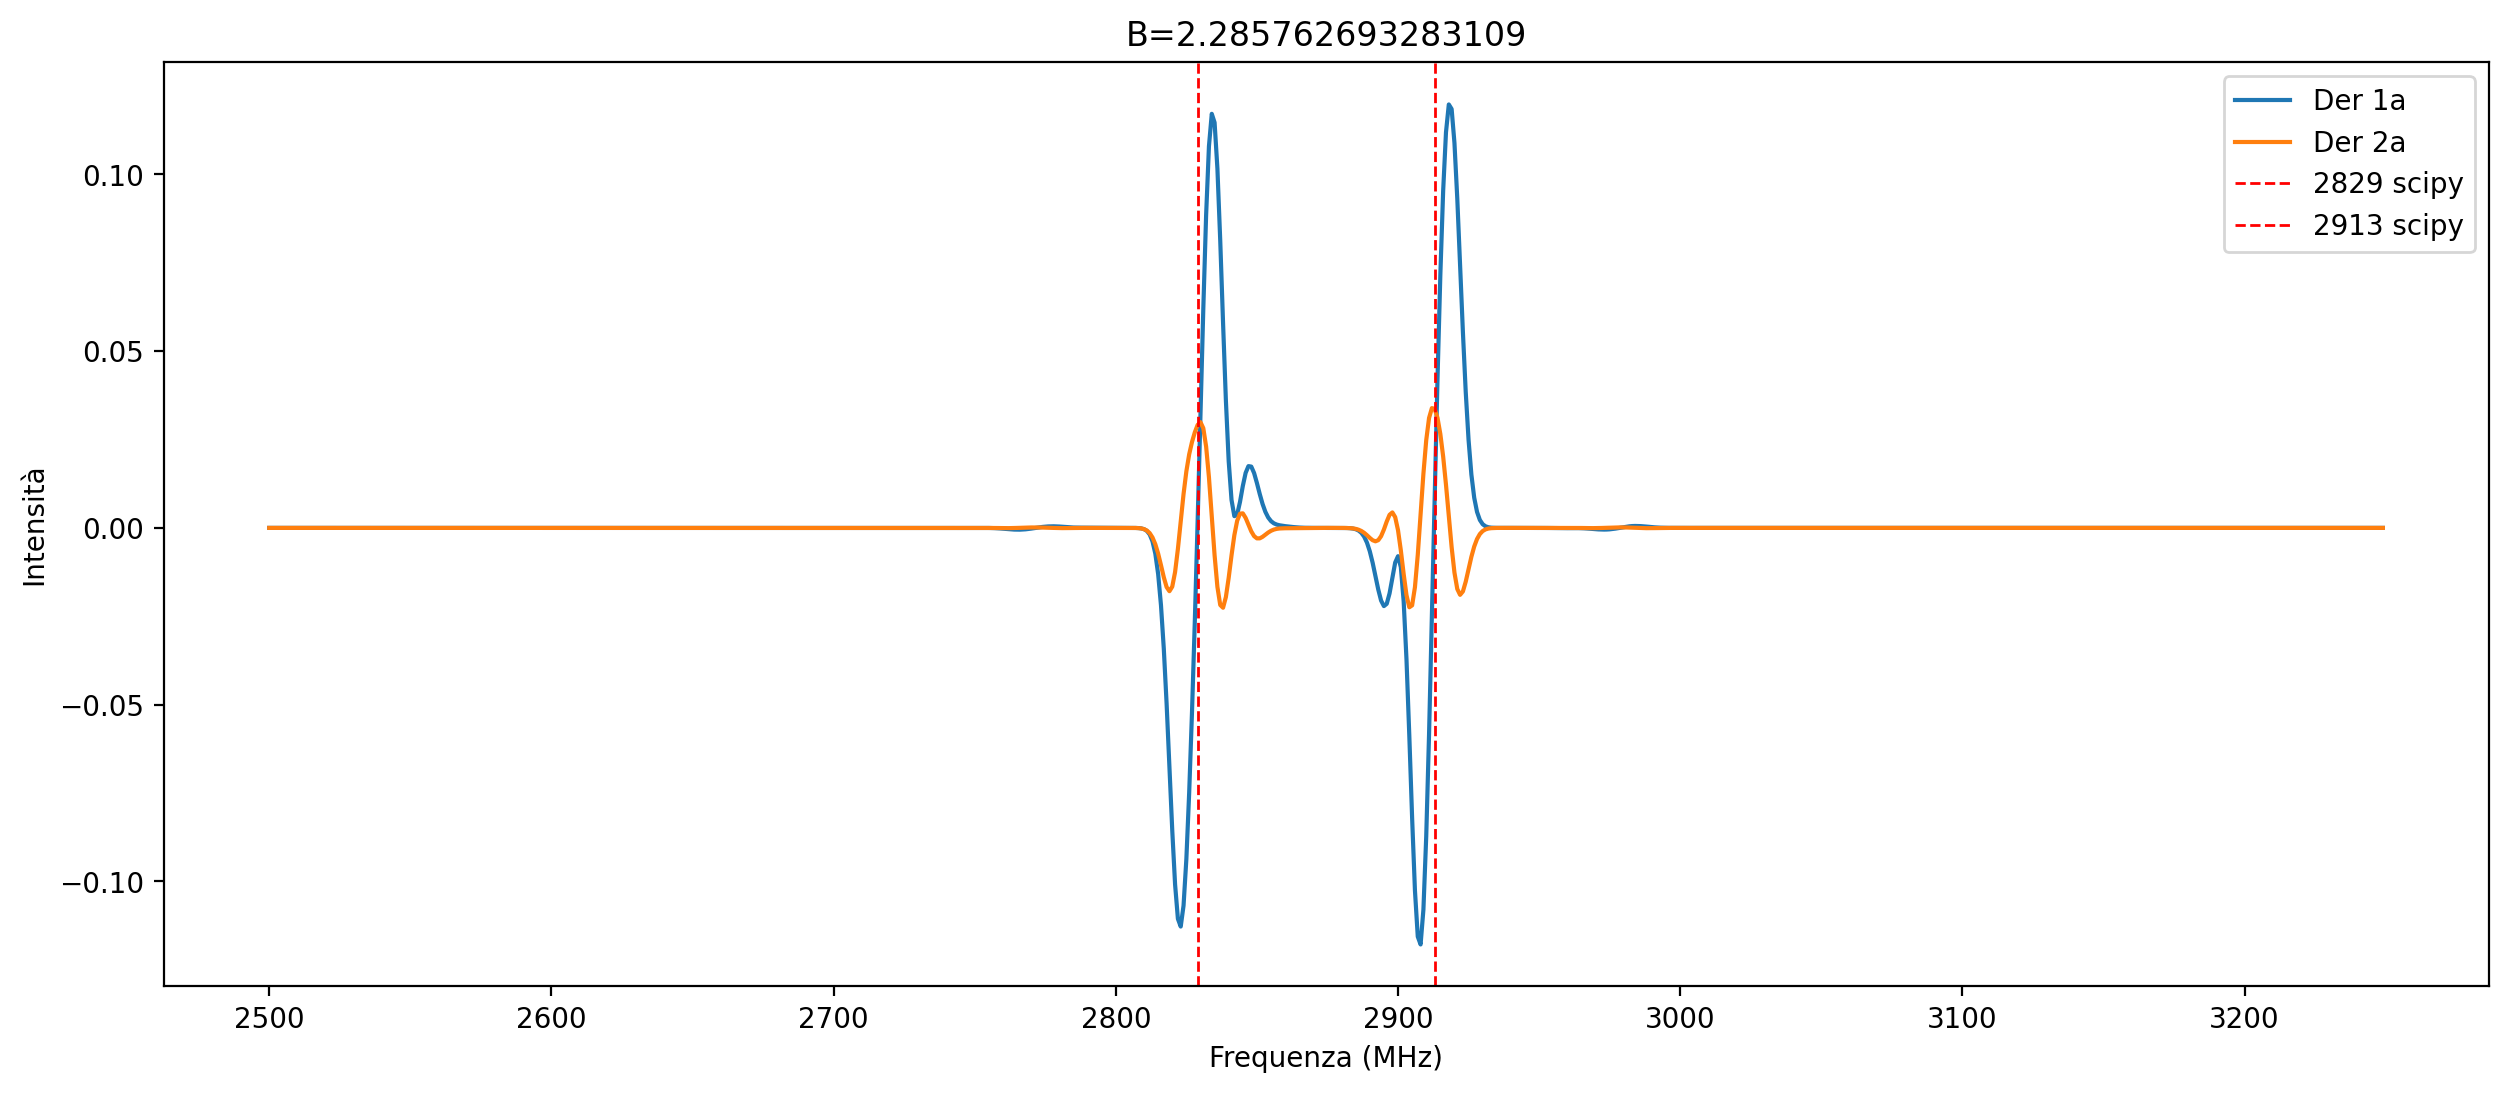

In [5]:
ds_df = np.gradient(s[2], f)
d2s_df2 = np.gradient(ds_df, f)

plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, ds_df, label='Der 1a')
plt.plot(x_axis, d2s_df2, label='Der 2a')
for pos in posizioni_totali[2]:
    h = info_totale[2]['peak_heights'][np.where(posizioni_totali[2] == pos)[0][0]]
    #plt.scatter(pos, -h/7, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
    plt.axvline(x=pos, color='red', linestyle='--', label=f'{pos} scipy', linewidth=1)  # Evidenziamo i picchi con linee verticali
plt.title(f"B={B[2]}")
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità')
plt.legend()
plt.show()

in teoria, i massimi della derivata seconda forniscono i picchi

In [6]:
pos_der2, info_der2 = trova_picchi_scipy(f, d2s_df2, soglia=0.001)

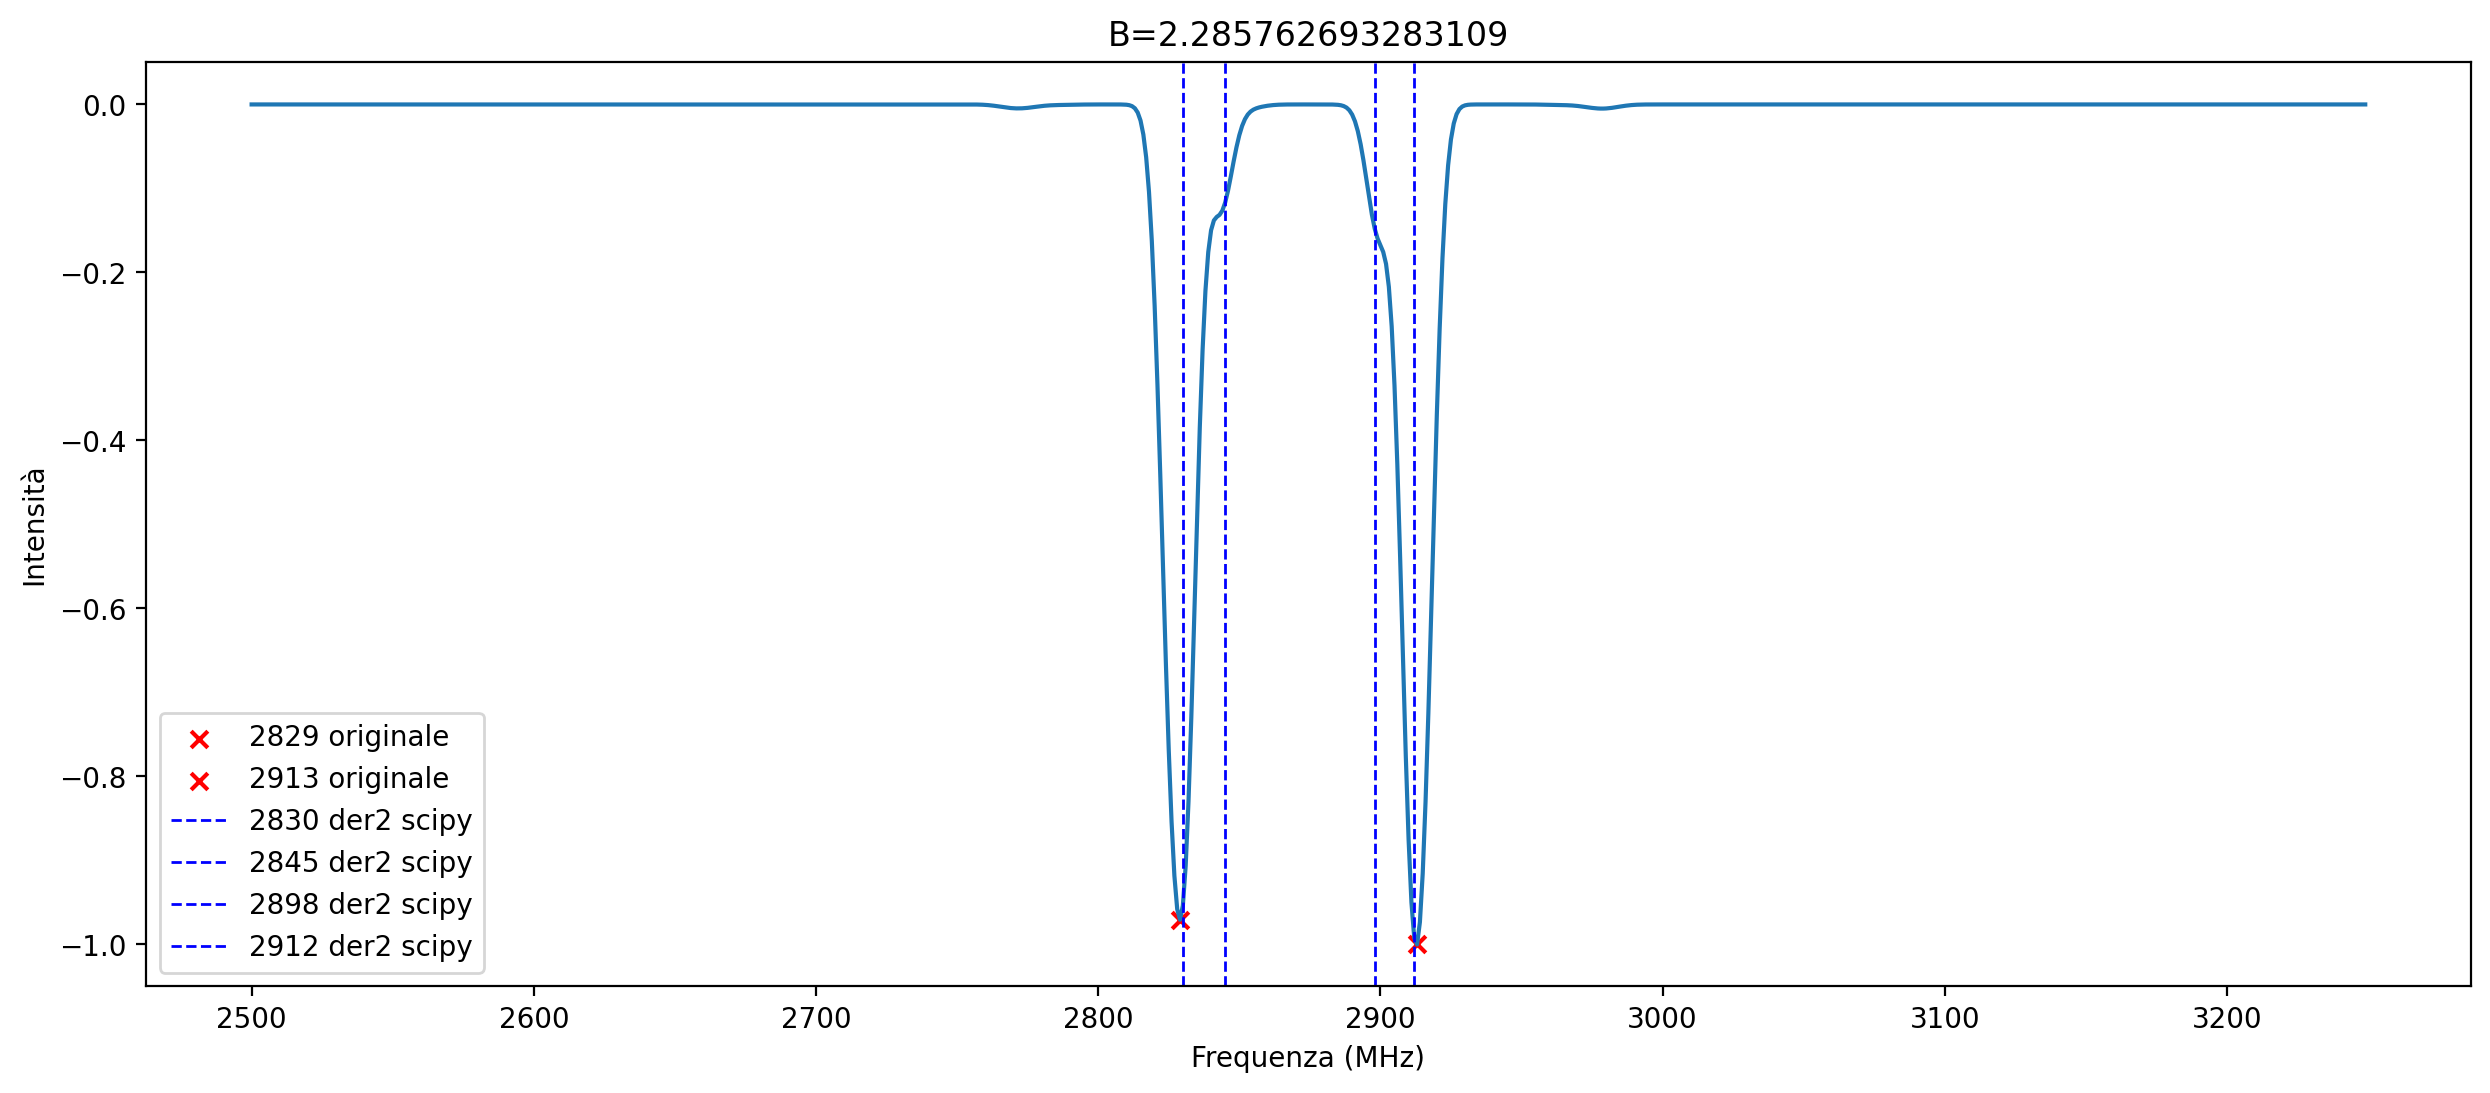

In [7]:
for k in range(2, 3):  # Visualizziamo i primi 10 spettri
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(x_axis, s[k])
    for pos in posizioni_totali[k]:
        h = info_totale[k]['peak_heights'][np.where(posizioni_totali[k] == pos)[0][0]]
        plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} originale')  # Evidenziamo i picchi
    for pos in pos_der2:
        plt.axvline(x=pos, color='blue', linestyle='--', label=f'{pos} der2 scipy', linewidth=1)  # Evidenziamo i picchi con linee verticali
    plt.title(f"B={B[k]}")
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
    plt.legend()
    plt.show()

### fit

---

Forse già qui si deve fare il fit multi-lorentziano. Bisogna assegnare un errore di qualche tipo allo spettro, in modo da avere un sistema per quantificare l'accordo tra fit e spettro. Se non c'è accordo, si può pensare «ehi, forse c'è da aggiungere una coppia di lorentziane»

Iniziamo col fittare lo spettro 2

In [ ]:
from scipy.optimize import curve_fit
from assign_labels import multi_lorentziana, fit_spettro, correggi_fit_spettro

amp_2 = info_totale[2]['peak_heights']  # Ampiezze dei picchi per lo spettro 2
pos_2 = posizioni_totali[2]  # Posizioni dei picchi per lo spettro 2
gamma_2 = info_totale[2]['widths']  # Stima di gamma dalla larghezza del picco

# popt, pcov = curve_fit(multi_lorentziana, f, s[2], p0=[pos_2, gamma_2])

amp_2_opt, pos_2_opt, gamma_2_opt = fit_spettro(f, s[2], amp_2, pos_2, gamma_2)

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Use of unsupported NumPy function 'numpy.tile' or unsupported use of the function.

File "assign_labels.py", line 51:
def otto_lorentziane(
    <source elided>
            raise ValueError("Il numero di posizioni deve essere pari per poter duplicare i parametri.")
        ampiezze = np.tile(ampiezze, 8 // N)
        ^

During: typing of get attribute at /Users/zosojack/ml-odmr/signal-syntesis/assign_labels.py (51)

File "assign_labels.py", line 51:
def otto_lorentziane(
    <source elided>
            raise ValueError("Il numero di posizioni deve essere pari per poter duplicare i parametri.")
        ampiezze = np.tile(ampiezze, 8 // N)
        ^

During: Pass nopython_type_inference

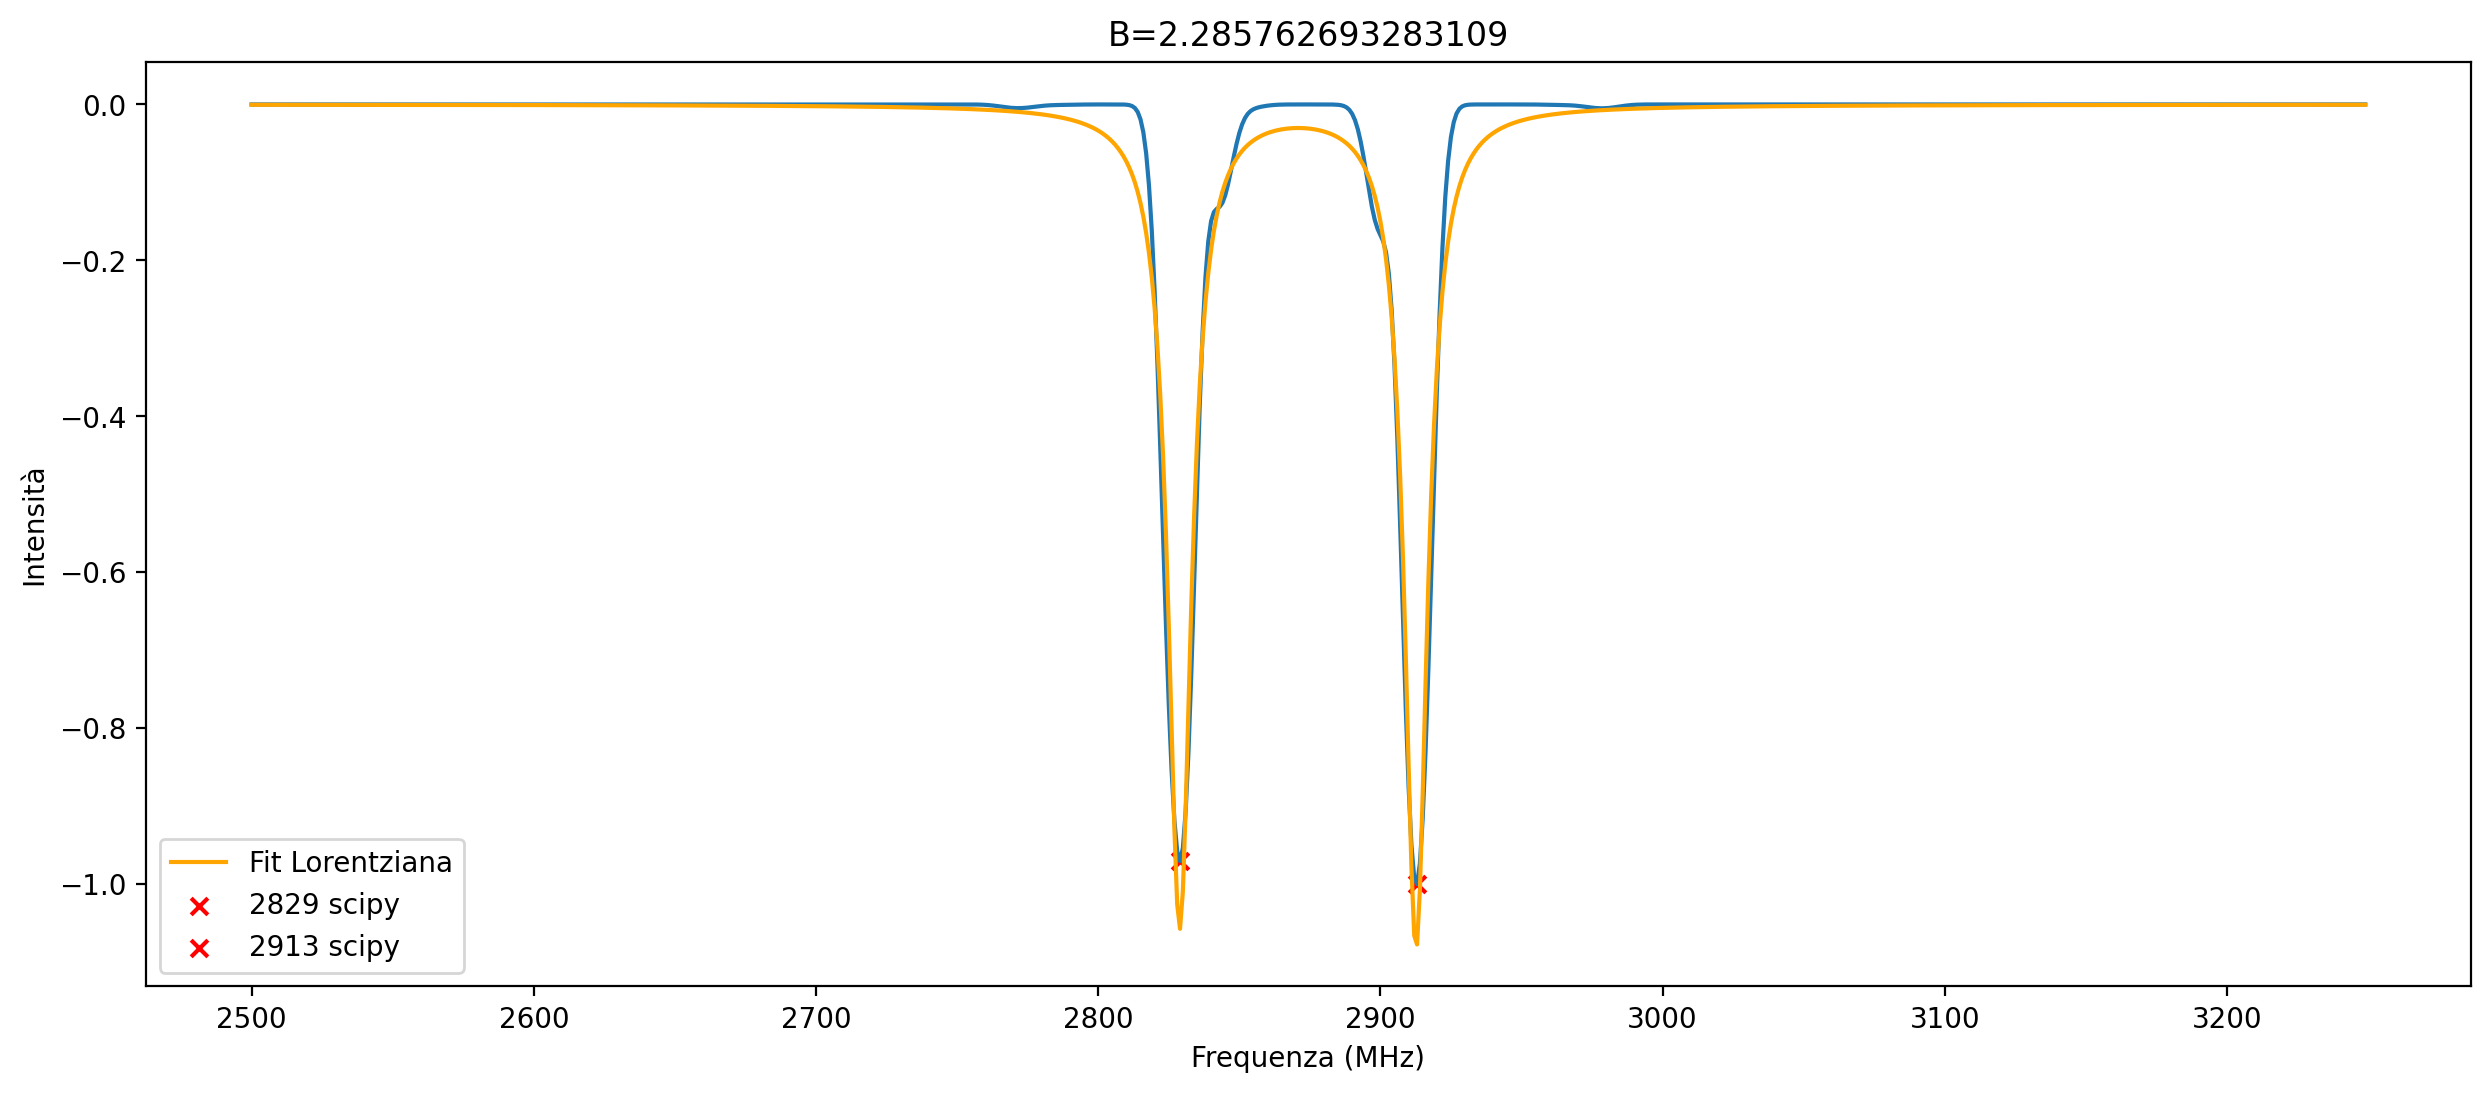

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, s[2])
plt.plot(x_axis, -multi_lorentziana(f, amp_2_opt, pos_2_opt, gamma_2_opt), color='orange', label='Fit Lorentziana')
for pos in posizioni_totali[2]:
    h = info_totale[2]['peak_heights'][np.where(posizioni_totali[2] == pos)[0][0]]
    plt.scatter(pos, -h, color='red', marker='x',label=f"{pos} scipy")  # Evidenziamo i picchi
plt.title(f"B={B[2]}")
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità')
plt.legend()
plt.show()

In [ ]:
# stampo i parametri ottimizzati
print("Ampiezze ottimizzate:", amp_2_opt)
print("Posizioni ottimizzate:", pos_2_opt)
print("Gamma ottimizzati:", gamma_2_opt)

Ampiezze ottimizzate: [5.34240855 5.36152817]
Posizioni ottimizzate: [2828.88937043 2912.63122359]
Gamma ottimizzati: [5.06825009 4.96635561]


chiaramente non va bene, quindi l'algoritmo deve valutare e notare che non va mica bene

In [ ]:
# considero un errore poissoniano
sigma = np.sqrt(np.abs(s[2]))
min_non_zero = np.min(sigma[sigma > 0])  # Trova il minimo non zero
sigma = np.where(sigma == 0, min_non_zero, sigma)  # Evitiamo divisioni per zero

# calcolo somma quadratica dei residui normalizzata per i gradi di libertà 
# (chi quadro ridotto)
res = s[2] + multi_lorentziana(f, amp_2_opt, pos_2_opt, gamma_2_opt)
chi_2 = np.sum((res - s[2])**2 / sigma**2)
chi_2_rid = chi_2 / (len(f) - 2 * len(pos_2_opt))

print(f"Chi quadro ridotto: {chi_2_rid:.4f}")

Chi quadro ridotto: 54361.5372


### uso i picchi trovati con der2

In [ ]:
n_picchi_d2 = len(pos_der2)

amp_2_der2 = np.array([1]*n_picchi_d2)  # Ampiezze dei picchi per lo spettro 2
gamma_2_der2 = np.array([10]*n_picchi_d2)  # Stima di gamma dalla larghezza del picco

# popt, pcov = curve_fit(multi_lorentziana, f, s[2], p0=[pos_2, gamma_2])

amp_2_der2_opt, pos_2_der2_opt, gamma_2_der2_opt = fit_spettro(f, s[2], amp_2_der2, pos_der2, gamma_2_der2)

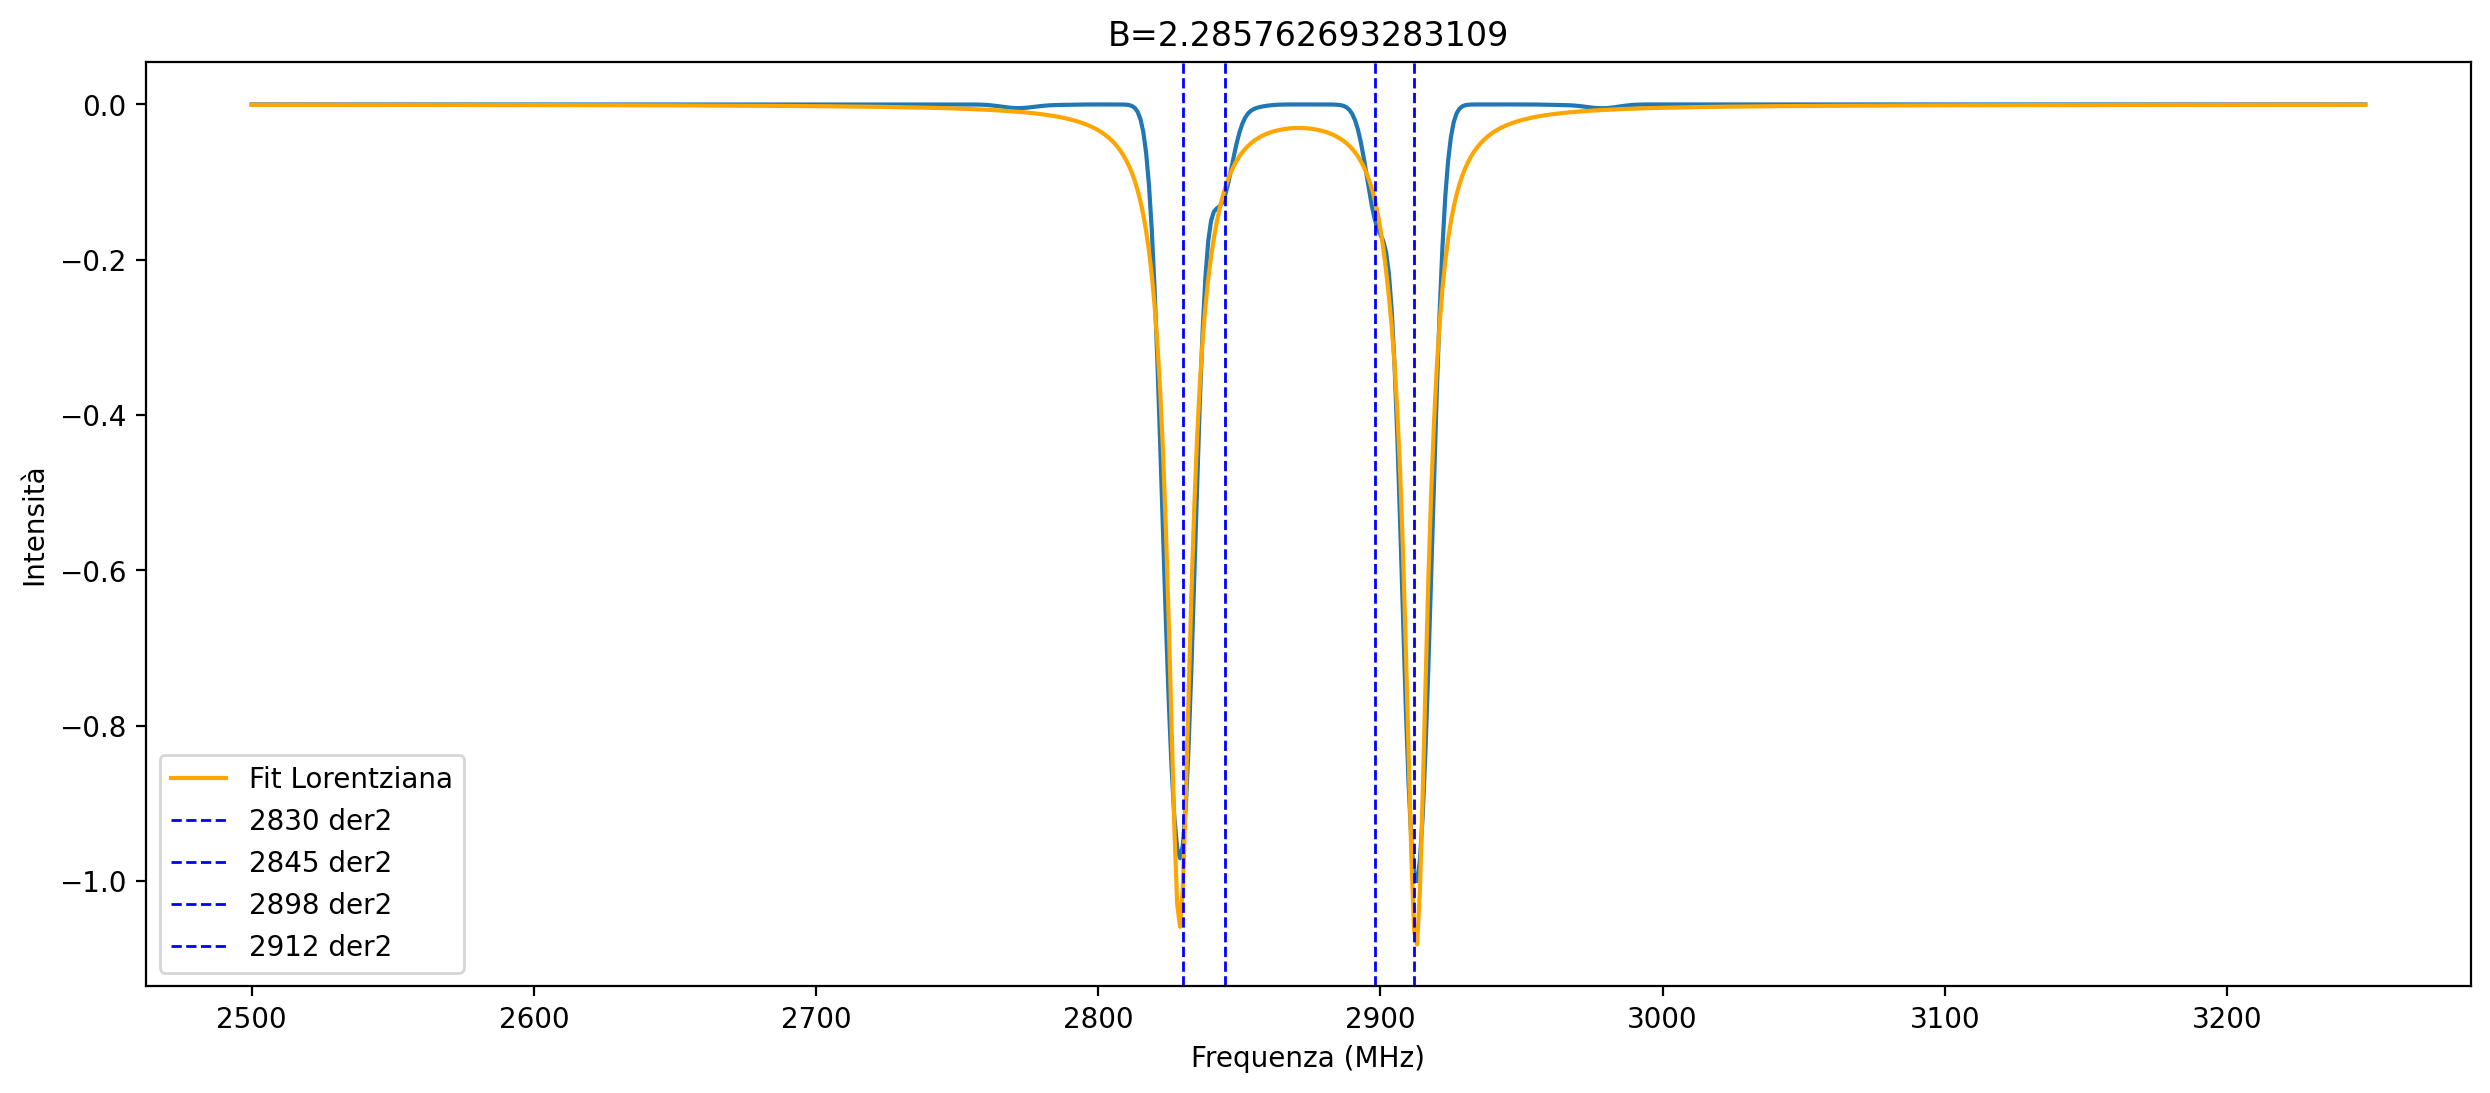

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, s[2])
plt.plot(x_axis, -multi_lorentziana(f, amp_2_der2_opt, pos_2_der2_opt, gamma_2_der2_opt), color='orange', label='Fit Lorentziana')
for pos in pos_der2:
    plt.axvline(x=pos, color='blue', linestyle='--', label=f'{pos} der2', linewidth=1)  # Evidenziamo i picchi con linee verticali
plt.title(f"B={B[2]}")
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità')
plt.legend()
plt.show()

In [ ]:
# stampo i parametri ottimizzati
print("Ampiezze ottimizzate:", amp_2_der2_opt)
print("Posizioni ottimizzate:", pos_2_der2_opt)
print("Gamma ottimizzati:", gamma_2_der2_opt)

Ampiezze ottimizzate: [5.26352207 0.1        0.1        5.26469707]
Posizioni ottimizzate: [2828.84586097 2840.00000175 2902.99999957 2912.69237265]
Gamma ottimizzati: [5.00340395 6.77921244 4.25134803 4.88214263]


### aggiunta manuale

proviamo ad aggiungere altre due lorentziane

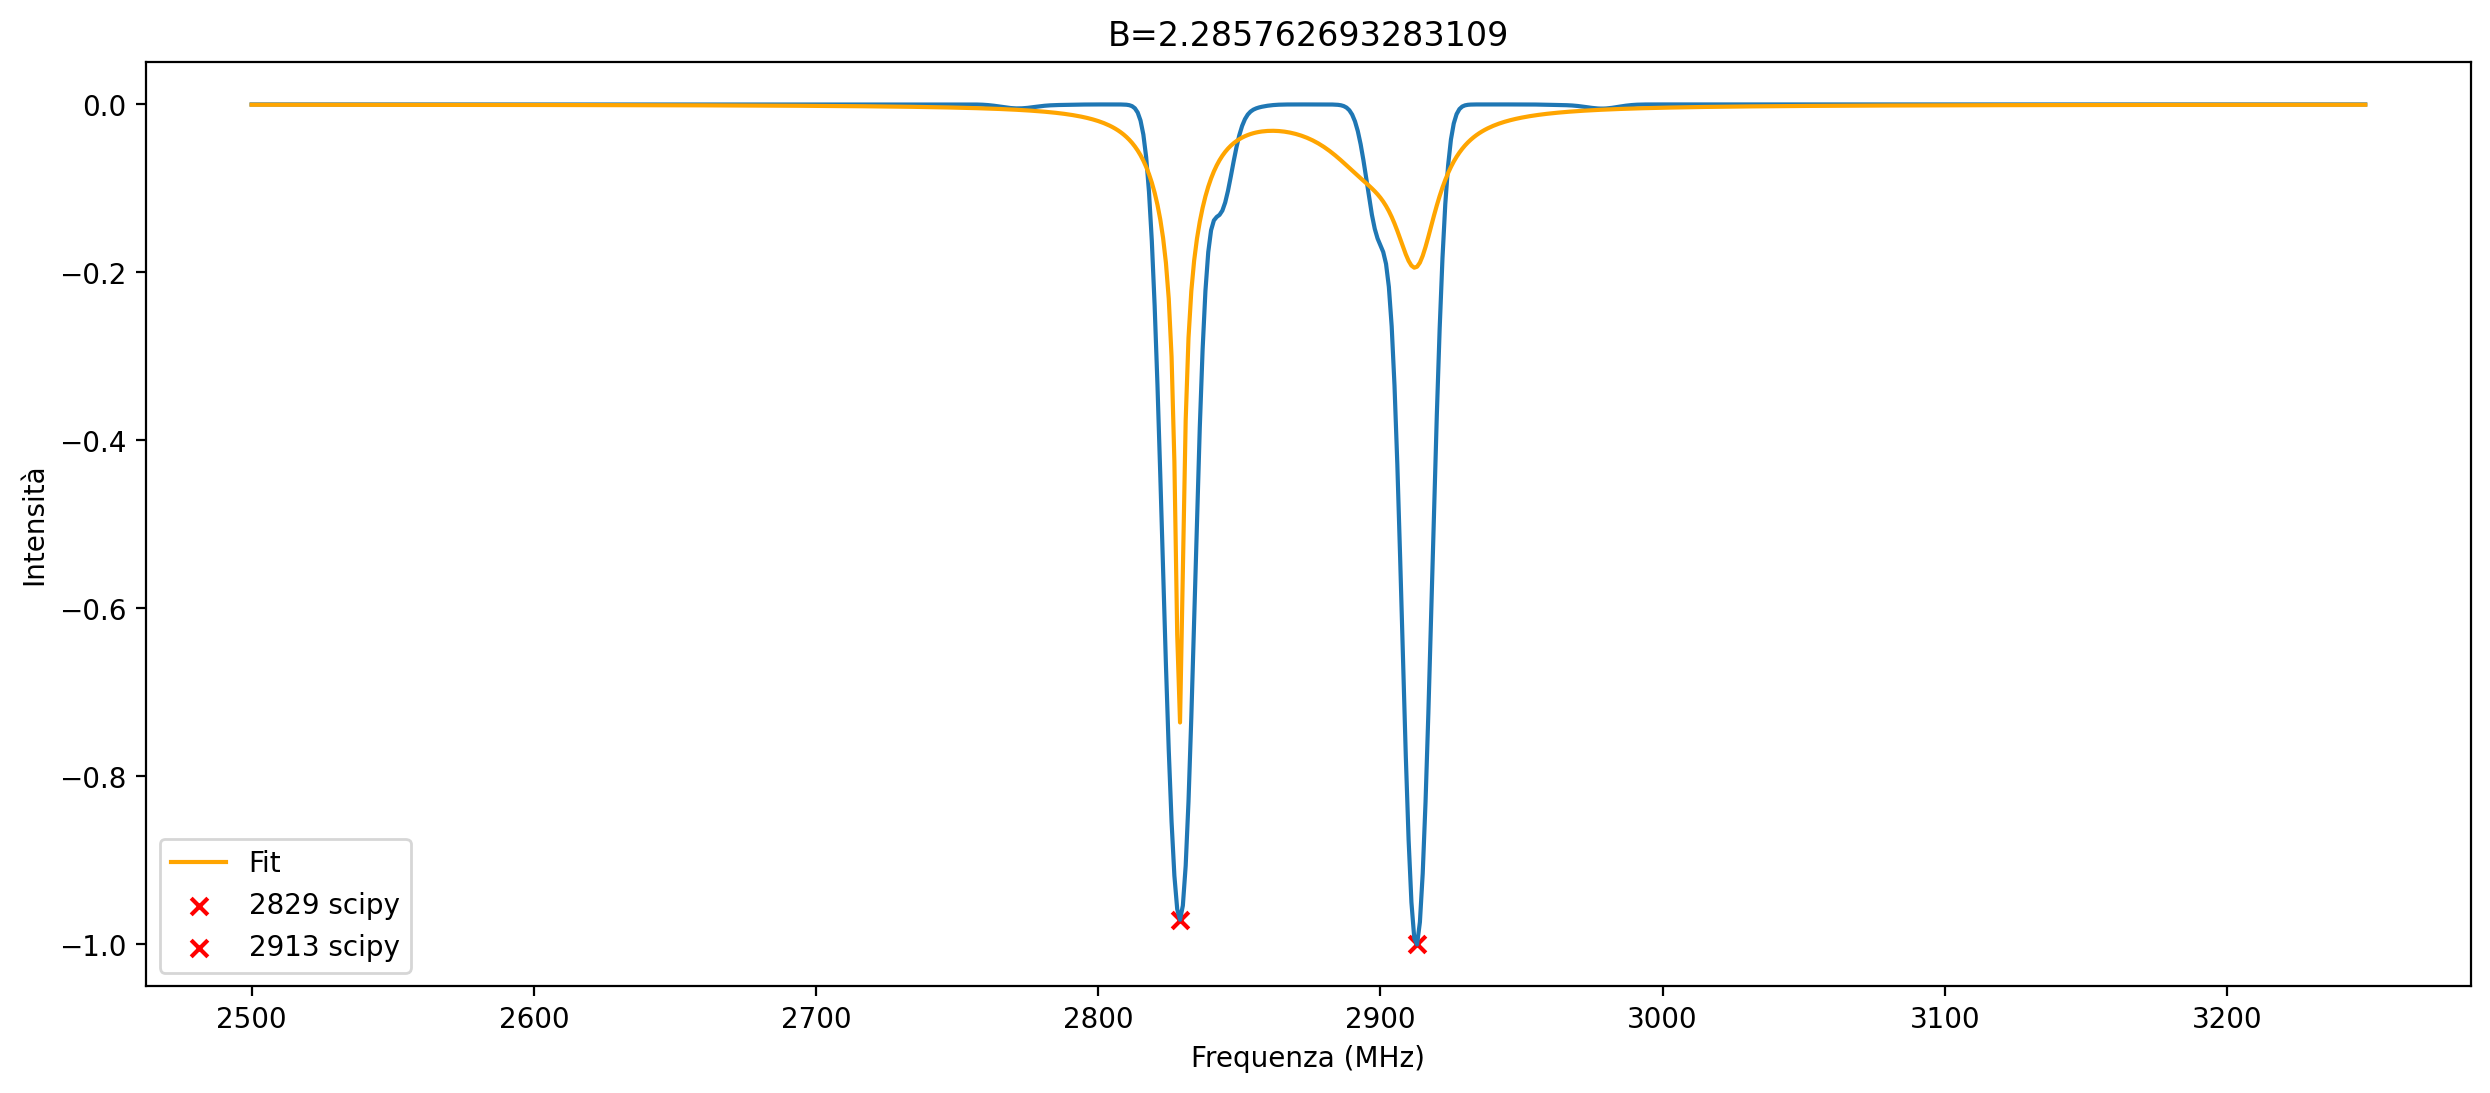

In [ ]:
amp_2_aggiunte = np.array([0.2, 0.2])
pos_2_aggiunte = np.array([2830, 2890])
gamma_2_aggiunte = np.array([10, 10])

amp_2_opt, pos_2_opt, gamma_2_opt = correggi_fit_spettro(
    f, 
    s[2],
    amp_2,
    pos_2,
    gamma_2,
    amp_2_aggiunte,
    pos_2_aggiunte,
    gamma_2_aggiunte
)

plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, s[2])
plt.plot(x_axis, -multi_lorentziana(f, amp_2_opt, pos_2_opt, gamma_2_opt), color='orange', label='Fit')
for pos in posizioni_totali[2]:
    h = info_totale[2]['peak_heights'][np.where(posizioni_totali[2] == pos)[0][0]]
    plt.scatter(pos, -h, color='red', marker='x', label=f"{pos} scipy")  # Evidenziamo i picchi

plt.title(f"B={B[2]}")
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità')
plt.legend()
plt.show()

In [ ]:
# stampo i parametri ottimizzati
print("Ampiezze ottimizzate:", amp_2_opt)
print("Posizioni ottimizzate:", pos_2_opt)
print("Gamma ottimizzati:", gamma_2_opt)

Ampiezze ottimizzate: [1.45590332 1.5        1.         1.        ]
Posizioni ottimizzate: [2829.18261617 2912.62571529 2828.81849598 2895.        ]
Gamma ottimizzati: [ 9.52527688  9.17503659  1.71333799 18.03776314]
